# Chapter V. Task

We will practice using a problem from Kaggle.com. You will predict the price of an apartment rental listing based on the listing content such as text description, photos, number of bedrooms, etc. The data comes from renthop.com, an apartment listing website.

Follow the instructions, answer the questions and get your final score!

## 1. Introduction. Write your answers in the Intro section of your notebook.

###
> I. To get started, please write 5 examples of the application of ML methods in life. What is the benefit of using machine learning methods in each of your examples?

1. для борьбы с вырубкой лесов: с помощью компьютерного зрения и спутниковых снимков выявляются зоны незаконной вырубки лесов; с помощью аудиоанализа ML сопоставляет их с естественными шумами так, чтобы выделить тот шум, который кореллирует с деятельностью, связанной с незаконной вырубкой леса
2. для выявления бракованных изделий на производстве: с помощью компьютерного зрения + ML можно снизить количество бракованной продукции
3. для диагностики заболеваний: ML быстро и точно сопоставляет данные анализов пациента для выявления потенциальных и скрытых заболеваний
4. для анализа геологоразведочных кернов: CV + ML по рентгеновским снимкам геологических кернов может создать 3d модель залежей полезных ископаемых и оценить их мощность
5. для прогнозирования цен на автомобили: ML может быстро и точно сопоставить закономерности ценообразования в различных сегментах экономики и тем самым предсказать цену

###
> II. Use the classification of tasks in the introduction to decide which class you can assign to the tasks from the table above and to the 5 examples you provided.

>> **_ДЛОдаоплдваоп_**

###
> III. Think about what the difference is between multiclass and multilabel.

>> **_ДЛОдаоплдваоп_**

###
> IV. Is an example case with house prices from the theory a classification of a regression problem? Is it possible to reduce the regression problem to classification?

>> **_ДЛОдаоплдваоп_**

## 2. Introduction to Data Analysis

###
> I. Import the libraries pandas, numpy, sklearn, lightgbm, scipy, statsmodels, matplotlib, seaborn. Use pip install if necessary.

In [1]:
import pandas as pd
import numpy as np
import sklearn as skl
import lightgbm
import scipy as sp
import statsmodels
from matplotlib import pyplot as plt
import seaborn as sb

###
> II. Load data from [kaggle](https://www.kaggle.com/competitions/two-sigma-connect-rental-listing-inquiries/data) using pandas. You only need the table data, which is in train.json.

In [2]:
train_df = pd.read_json(
    '../datasets/train.json',
    # dtype={'bathrooms': np.int16,'bedrooms': np.int16}
)

###
> III. What is the size (the number of rows and columns) of your data?

In [3]:
train_df.shape

(49352, 15)

###
> IV. Print the list of columns. Which column is a target?

In [4]:
print(*train_df.columns, sep='\n')  # target column: "price"

bathrooms
bedrooms
building_id
created
description
display_address
features
latitude
listing_id
longitude
manager_id
photos
price
street_address
interest_level


###
> V. Make a quick analysis of the data: use the methods info(), describe(), corr(). Explain the results of the outputs. Are there any empty columns?

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  object 
 3   created          49352 non-null  object 
 4   description      49352 non-null  object 
 5   display_address  49352 non-null  object 
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  object 
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  object 
 14  interest_level   49352 non-null  object 
dtypes: float64(3), int64(3), object(9)
memory usage: 6.0+ MB


In [6]:
train_df.describe()

,bathrooms,bedrooms,latitude,listing_id,longitude,price
count,49352.00000,49352.000000,49352.000000,4.935200e+04,49352.000000,4.935200e+04
mean,1.21218,1.541640,40.741545,7.024055e+06,-73.955716,3.830174e+03
std,0.50142,1.115018,0.638535,1.262746e+05,1.177912,2.206687e+04
min,0.00000,0.000000,0.000000,6.811957e+06,-118.271000,4.300000e+01
25%,1.00000,1.000000,40.728300,6.915888e+06,-73.991700,2.500000e+03
50%,1.00000,1.000000,40.751800,7.021070e+06,-73.977900,3.150000e+03
75%,1.00000,2.000000,40.774300,7.128733e+06,-73.954800,4.100000e+03
max,10.00000,8.000000,44.883500,7.753784e+06,0.000000,4.490000e+06


In [7]:
train_df.corr(numeric_only=True)

,bathrooms,bedrooms,latitude,listing_id,longitude,price
bathrooms,1.000000,0.533446,-0.009657,0.000776,0.010393,0.069661
bedrooms,0.533446,1.000000,-0.004745,0.011968,0.006892,0.051788
latitude,-0.009657,-0.004745,1.000000,0.001712,-0.966807,-0.000707
listing_id,0.000776,0.011968,0.001712,1.000000,-0.000907,0.008090
longitude,0.010393,0.006892,-0.966807,-0.000907,1.000000,-0.000087
price,0.069661,0.051788,-0.000707,0.008090,-0.000087,1.000000


In [8]:
train_df.isna().any()

bathrooms          False
bedrooms           False
building_id        False
created            False
description        False
display_address    False
features           False
latitude           False
listing_id         False
longitude          False
manager_id         False
photos             False
price              False
street_address     False
interest_level     False
dtype: bool

###
> VI. We'll work with only 3 features: 'bathrooms', 'bedrooms', 'interest_level' and with the target column 'price'. Create a dataframe with only these columns.

In [9]:
df = train_df[['bathrooms', 'bedrooms', 'interest_level', 'price']].copy()
df.shape

(49352, 4)

## 3. Statistical Data Analysis

###
> I. To get started with statistical data analysis, we recommend that you refresh your basic knowledge of statistics, such as Mean / Median / Mode / Variance / Standard Deviation. Also you are welcome to be free with distributions (Discrete uniform Distribution, Bernoulli Distribution, Binomial Distribution, Poisson Distribution, Normal Distribution, Exponential Distribution). Please make sure that you know the definitions of outliers, percentiles, confidential intervals. The article will be presented later.

###
> II. Have a quick look at this [article](https://towardsdatascience.com/how-to-compare-two-or-more-distributions-9b06ee4d30bf/). Please pay attention to such aspects as distributions and histograms, boxplots, outliers, kernel density function.

###
> III. Target analysis

####
> a. Plot a histogram to understand the distribution of the target. Is it all clear?

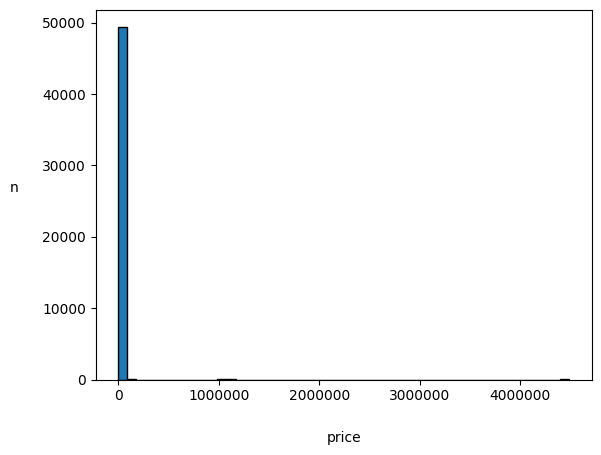

In [10]:
plt.xlabel('price', labelpad=20)
plt.ylabel('n', labelpad=20, rotation=0)
plt.ticklabel_format(style='plain')
plt.hist(df['price'], bins=50, edgecolor='black')
plt.show()

####
> b. The next step is boxplot(). What can you say about the target? Are there any outliers?

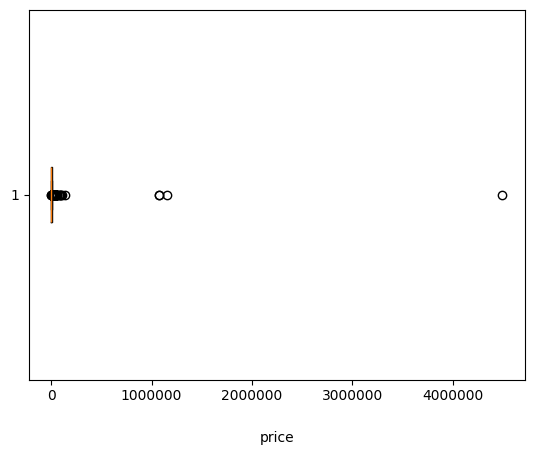

In [11]:
plt.xlabel('price', labelpad=20)
plt.ticklabel_format(style='plain', axis='x')
plt.boxplot(df['price'], vert=False)
plt.show()

####
> c. Drop the rows that are outside the 1 and 99 percentiles from the target column.

In [12]:
percentile_1 = df['price'].quantile(0.01)
percentile_99 = df['price'].quantile(0.99)
# df = df[df['price'].between(percentile_1, percentile_99)].copy()
df = df[(df['price'] > percentile_1) & (df['price'] < percentile_99)].copy()

####
> d. Plot another histogram for price. Explain the result.

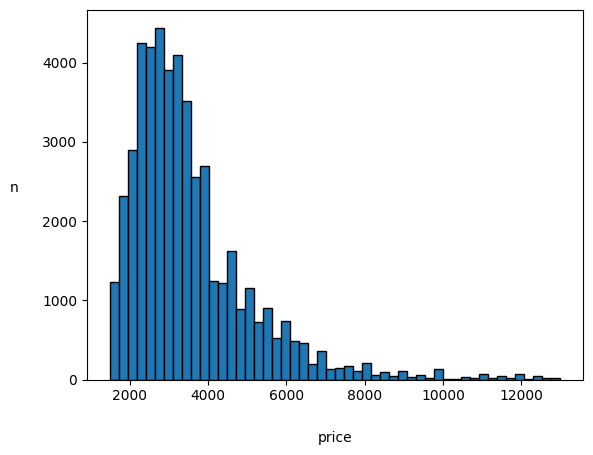

In [13]:
plt.xlabel('price', labelpad=20)
plt.ylabel('n', labelpad=20, rotation=0)
plt.ticklabel_format(style='plain')
plt.hist(df['price'], bins=50, edgecolor='black')
plt.show()

###
> IV. Characteristics Analysis

####
> a. What is the type of column 'interest_level'?

In [14]:
df['interest_level'].dtype  # df.dtypes: 'interest_level': object == 'O'

dtype('O')

####
> b. Print the values in this column. How many entries does each value contain?

In [15]:
df['interest_level'].value_counts()

interest_level
low       33672
medium    11114
high       3557
Name: count, dtype: int64

####
> c. Encode these values. For example, you can replace each value with 0, 1, or 2.

In [16]:
df['interest_level'] = np.select(
    [(df['interest_level'] == 'low'), (df['interest_level'] == 'high')],
    [0, 2],
    default=1)

####
> d. Plot histograms for the features 'bathrooms', 'bedrooms'. Are there any outliers?

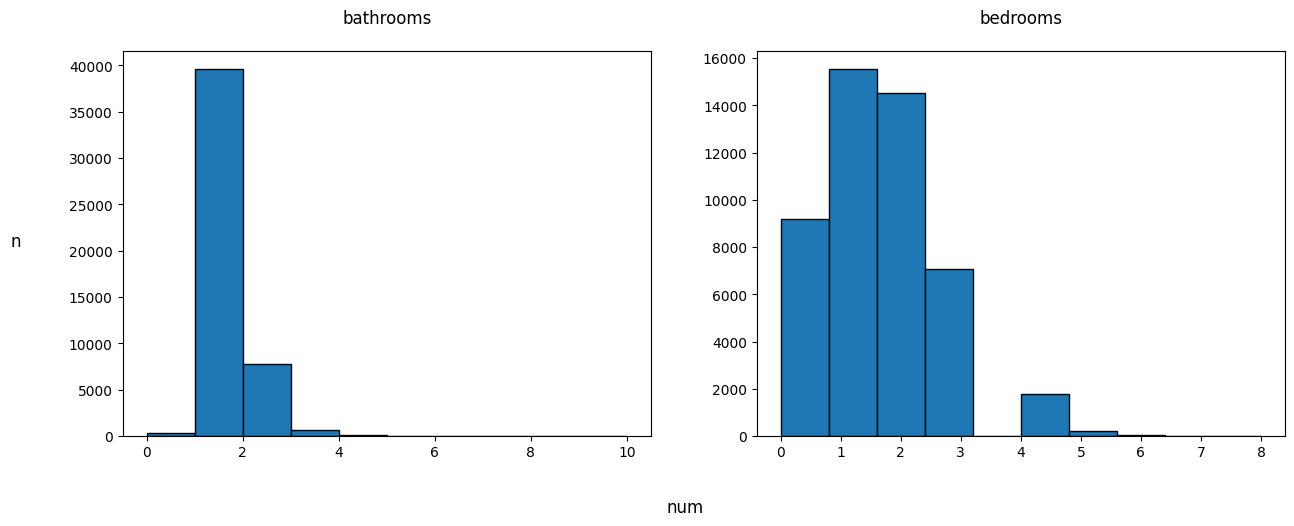

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
fig.supxlabel('num', y=-0.05)
fig.supylabel('n', x=0.05, rotation=0)

axs[0].set_title('bathrooms', pad=20)
axs[1].set_title('bedrooms', pad=20)

df['bathrooms'].hist(ax=axs[0], edgecolor='black')
df['bedrooms'].hist(ax=axs[1], edgecolor='black')

axs[0].grid(False)
axs[1].grid(False)
plt.show()

###
> V. Complex analysis

####
> a. Plot a correlation matrix to understand the correlation between features and target. Plot a heat map for the correlation matrix. Is there a correlation?

In [18]:
df.corr().round(6)

,bathrooms,bedrooms,interest_level,price
bathrooms,1.000000,0.517200,-0.062819,0.670808
bedrooms,0.517200,1.000000,0.051282,0.547310
interest_level,-0.062819,0.051282,1.000000,-0.199652
price,0.670808,0.547310,-0.199652,1.000000


####
> b. Plot a scatterplot to visualize the correlation between the features and the target. You should return 3 plots where the X-axis is the target and the Y-axis is a feature.

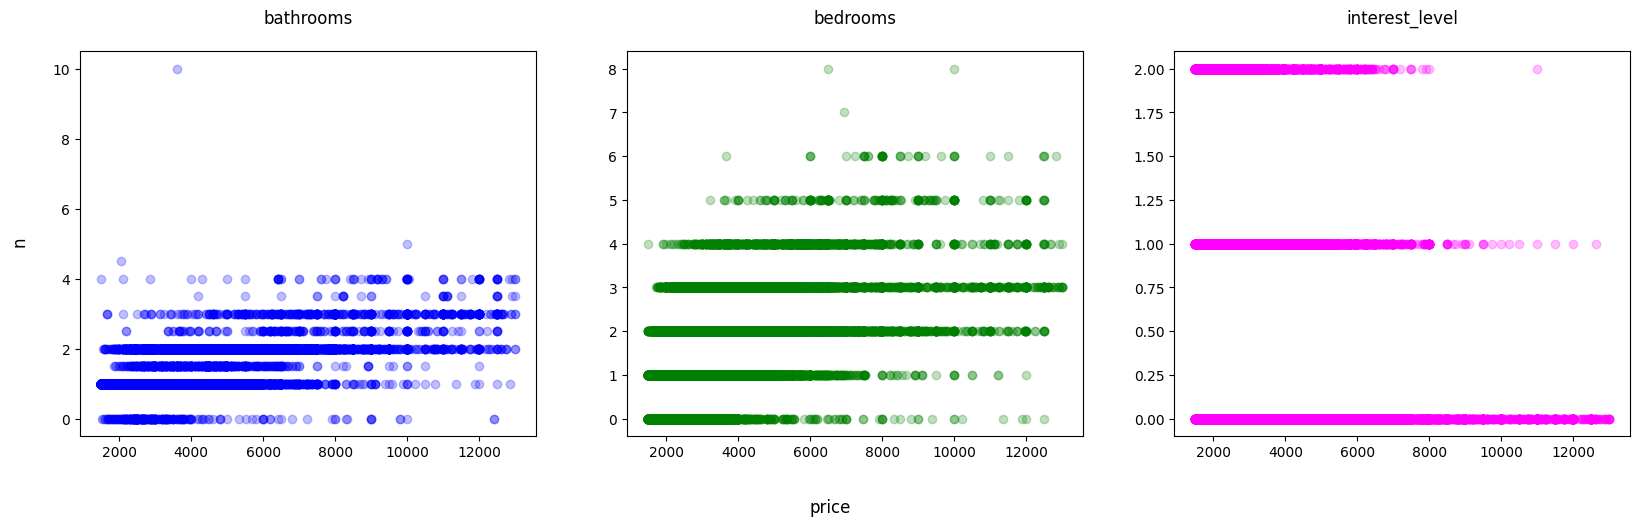

In [19]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5))

axs[0].scatter(df['price'], df['bathrooms'], color='blue', alpha=0.25)
axs[0].set_title('bathrooms', pad=20)
axs[1].scatter(df['price'], df['bedrooms'], color='green', alpha=0.25)
axs[1].set_title('bedrooms', pad=20)
axs[2].scatter(df['price'], df['interest_level'], color='magenta', alpha=0.25)
axs[2].set_title('interest_level', pad=20)

fig.supxlabel('price', y=-0.05)
fig.supylabel('n', x=0.09)

plt.show()

## 4. Creating Features

###
> I. This step is very broad. You can create as many features as you want. For example, you can add 3 new features that are squared: 'bathrooms_squared', 'bedrooms_squared', ''interest_level_squared'. Plot a correlation matrix with the new features. Are the new features more correlated with the target than the basic features?

###
> II. To train the model here, we will not use your new features. Remember this example and use it in Lecture 2. To train the model, we will only consider the features 'bathrooms' and 'bedrooms'.

###
> III. Read this Sklearn info about [PolynomialFeatures](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html).

###
> IV. To use PolynomialFeatures, we first need to split the data into training and test samples. We have already done this for you, please read the training and test data.

###
> V. Initialize PolynomialFeatures() with a degree of 10.

###
> VI. Apply PolynomialFeatures() to fit and transform your training and test data.

## 5. Now you need to train 3 models: linear regression, decision tree and naive model. We will use them as black boxes without deep understanding.

###
> I. Results table

####
> a. Create two empty Pandas DataFrames with columns 'model', 'train', 'test'. Let's call the first one result_MAE and the second one result_RMSE. We will fill these tables with the results of the models.

###
> II. Linear Regression

####
> a. Initialize linear regression from **sklearn** with no parameters.

####
> b. Fit your model and make predictions on training and test features. Save it as new columns in data.

####
> c. Compute MAE (Mean Absolute Error) on training and test targets.

####
> d. Calculate RMSE (Root Mean Square Error) on training and test objectives.

####
> e. Insert your metrics into tables result_MAE and result_RMSE with model name 'linear_regression'.

###
> III. Decision Tree

####
> a. Initialize decision tree regressor from sklearn with fixed random_state=21.

####
> b. Fit it to train features and train target and make prediction on train and test features. Save it as a new column in data.

####
> c. Compute MAE (Mean Absolute Error) on train and test targets.

####
> d. Compute RMSE (Root Mean Square Error) on train and test targets.

####
> e. Insert your metrics into tables result_MAE and result_RMSE with model name 'decision_tree'.

###
> IV. Naive Models

####
> a. Calculate the mean and median of 'price' on the training and test data and create a column with these values.

####
> b. Calculate the MAE on the training and test targets between your target and the calculated mean and median.

####
> c. Calculate the RMSE on the training and test targets between your target and the calculated mean and median.

####
> d. Insert your metrics into tables result_MAE and result_RMSE with model names 'naive_mean' and 'naive_median'.

###
> V. Compare the results

####
> a. Print your final result_MAE and result_RMSE tables.

####
> b. Which is the best model?

###
> VI. Additional

####
> a. You can practice with all the data in your starting dataset. Use and generate all the features you want.